# Launch readiness: schedule and resource-collision analysis

This notebook runs the readiness model's date logic in **SQL (SQLite)** and analyzes it with **pandas**.

The inputs are 52 readiness dependencies and two markets (Michigan, California) with go-live dates 42 days apart. It uses the worked-example statuses, as of 2026-09-26.

The core logic lives in two SQL views, and the tests hold both to the TypeScript engine row for row:

- `schedule` computes each item's latest start with `date(go_live, '-N days')`.
- `flagged` applies the overdue and at-risk rules.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pipeline

con = pipeline.connect()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.read_sql_query("SELECT * FROM markets", con)

,market_id,name,go_live
0,mi,Michigan,2027-01-11
1,ca,California,2027-02-22


## 1. Scoreboard

In [2]:
pipeline.run(con, "01")

,overdue_or_blocked,start_within_21_days,pct_done,dependencies
0,4,5,5.0,104


## 2. What's overdue right now?

In [3]:
pipeline.run(con, "02")

,market,workstream,item,owner,status,latest_start,days_late
0,Michigan,Licensure and credentialing,Payer credentialing and delegated roster submi...,Credentialing,blocked,2026-09-13,13
1,Michigan,Licensure and credentialing,Behavioral health licensure and supervision pa...,Legal,notstarted,2026-09-23,3
2,California,Payer contract and data,Eligibility and claims file specification agre...,Clinical Ops,notstarted,2026-09-25,1
3,California,Licensure and credentialing,"NP scope, supervision or collaboration require...",Legal,notstarted,2026-09-25,1


## 3. Where the two launches collide
These are the weeks in which central functions must start work for **both** markets.

,start_week,mi,ca,total
0,2026-11-02,5,2,7
1,2026-11-23,3,3,6
2,2026-12-14,1,5,6
3,2026-12-28,1,4,5
4,2026-11-09,2,2,4
5,2026-12-07,3,1,4
6,2026-10-19,1,2,3
7,2026-12-21,1,2,3


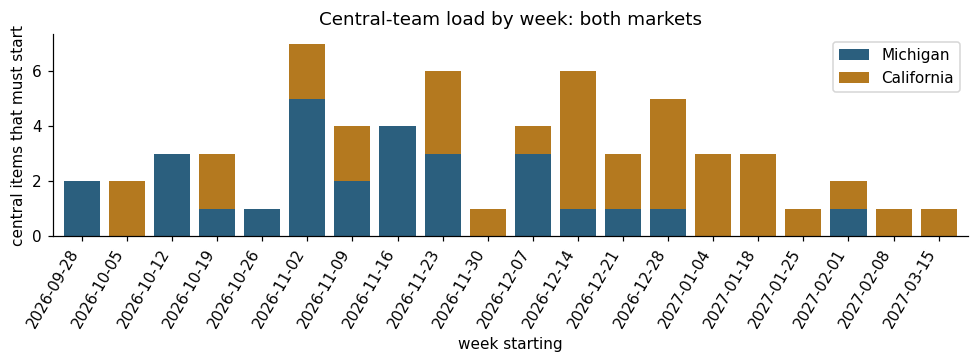

In [4]:
weekly = pd.read_sql_query("""
    SELECT start_week, SUM(market_id = 'mi') AS Michigan, SUM(market_id = 'ca') AS California
    FROM schedule, params
    WHERE is_central = 1 AND start_week >= as_of
    GROUP BY start_week ORDER BY start_week
""", con).set_index("start_week")
ax = weekly.plot.bar(stacked=True, figsize=(9, 3.4), color=["#2B5F7E", "#B4791F"], width=0.8)
ax.set_xlabel("week starting"); ax.set_ylabel("central items that must start")
ax.set_title("Central-team load by week: both markets")
plt.xticks(rotation=60, ha="right"); plt.tight_layout(); plt.savefig("figures/collision_weeks.png")
pipeline.run(con, "03")

## 4. Which central functions carry both launches?

,owner,total_starts,peak_month,starts_in_peak_month,both_markets_in_peak
0,Clinical Ops,36,2026-12,10,1
1,Legal,10,2026-08,3,1
2,Product,10,2026-11,5,1
3,L&D,6,2026-11,2,1
4,Credentialing,4,2026-10,2,1
5,IT,4,2026-12,2,1
6,Marketing,2,2026-11,1,0
7,People Ops,2,2026-09,1,0


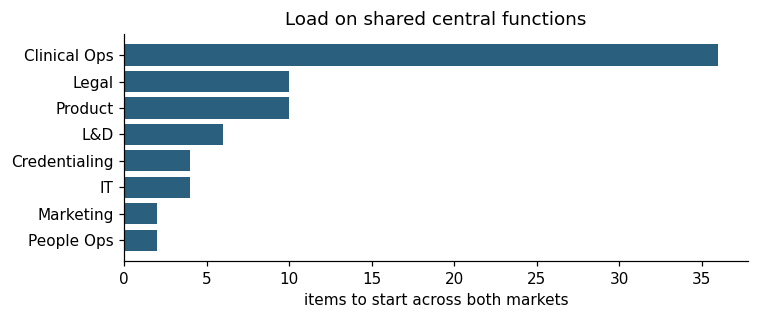

In [5]:
load = pipeline.run(con, "04")
fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(load.owner[::-1], load.total_starts[::-1], color="#2B5F7E")
ax.set_xlabel("items to start across both markets"); ax.set_title("Load on shared central functions")
plt.tight_layout(); fig.savefig("figures/central_load.png")
load

## 5. Workstream readiness by market

In [6]:
pipeline.run(con, "05")

,workstream,michigan_done,california_done,late,at_risk
0,Payer contract and data,2/5,0/5,1,0
1,Licensure and credentialing,2/8,0/8,3,2
2,Clinical staffing,1/6,0/6,0,1
3,Training and onboarding,0/6,0/6,0,1
4,Platform configuration,0/8,0/8,0,0
5,Vendors and supply,0/7,0/7,0,1
6,Workflows and documentation,0/7,0/7,0,0
7,Go-live and stabilization,0/5,0/5,0,0


## 6. Items that set the critical path

In [7]:
pipeline.run(con, "06")

,name,owner,lead_days,mi_latest_start,ca_latest_start
0,Contract executed with performance terms and a...,Payer Growth,210,2026-06-15,2026-07-27
1,"Entity, corporate practice structure and capit...",Legal,200,2026-06-25,2026-08-06
2,Market dyad hired: medical director and market...,Recruiting,180,2026-07-15,2026-08-26
3,"NP scope, supervision or collaboration require...",Legal,150,2026-08-14,2026-09-25
4,Eligibility and claims file specification agre...,Clinical Ops,150,2026-08-14,2026-09-25
5,Professional liability coverage extended to th...,Legal,140,2026-08-24,2026-10-05
6,Panel-size assumption set and staffing ramp mo...,Clinical Ops,135,2026-08-29,2026-10-10
7,"Clinician state licenses verified, including c...",People Ops,120,2026-09-13,2026-10-25


## Takeaways

1. **Clinical Ops is the bottleneck.** It owns 36 of 74 central starts (about half) across both launches, and its busiest month, December, has work due for both markets.
2. **The go-live dates are 42 days apart, but that doesn't stagger the work.** Nine upcoming weeks still need central starts for both markets, and the heaviest week (Nov 2) needs seven.
3. **The blocked credentialing roster is 13 days late** and sits on the licensure path. Unblocking it is the highest-leverage action this week.